# Compare `MaskedLMExplainer` (original) vs `MaskedLMExplainerImproved` (fixed)

Sanity-checks the fixes in [`explain/explain_improved.py`](explain/explain_improved.py) against
[`explain/explain.py`](explain/explain.py) on a handful of example sentences/targets:

1. **Token-level comparison table** — original vs improved score per token, plus how much
   attribution the original silently drops on `[CLS]`/`[SEP]`.
2. **Visual side-by-side** — the same sentences rendered with both explainers via
   `plot_highlighted_sentences`.
3. **CLS/SEP leakage across all examples** — bar chart, original vs improved.
4. **Multi-token target check** — confirms the fix still works when a target word splits
   into more than one subword.

Swap `model_name` below for whatever checkpoint you're currently working with.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, ".")

import pandas as pd
import matplotlib.pyplot as plt

from explain.explain import MaskedLMExplainer
from explain.explain_improved import MaskedLMExplainerImproved
from explain.visualise import plot_highlighted_sentences
from explain.tools import pick_device


## Load both explainers on the same model

In [2]:
model_name = "Livingwithmachines/bert_1760_1900"  # swap for the checkpoint you're comparing on
device = pick_device()

explainer_orig = MaskedLMExplainer(model_name=model_name, device=device)
explainer_imp = MaskedLMExplainerImproved(model_name=model_name, device=device)


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: Livingwithmachines/bert_1760_1900
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: Livingwithmachines/bert_1760_1900
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Example sentences & targets

In [3]:
examples = [
    ("The old [MASK] rattled loudly in the factory yard.", "machine"),
    ("She carefully oiled the [MASK] before the long journey.", "engine"),
    ("The clerk recorded every transaction in the great ledger by [MASK].", "hand"),
    ("Fine ladies are obsolete; they vanished when sewing [MASK] came in.", "girls"),
    ("Fine ladies are obsolete; they vanished when sewing [MASK] came in.", "machines"),
    ('His face had grown animated; until now he had been a [MASK], suddenly he became a man.', "boy"),
    ('His face had grown animated; until now he had been a [MASK], suddenly he became a man.', "machine"),
        
    # deliberately a word likely to split into multiple wordpieces, to exercise
    # the K>1 mask / multi-token target path:
    ("The new [MASK] transformed the textile industry overnight.", "mechanisation"),
]

# quick check of which targets are single- vs multi-token for this tokenizer
for sent, tgt in examples:
    n = len(explainer_orig._target_to_token_ids(tgt))
    print(f"{tgt!r:16s} -> {n} subword token(s)")


'machine'        -> 1 subword token(s)
'engine'         -> 1 subword token(s)
'hand'           -> 1 subword token(s)
'girls'          -> 1 subword token(s)
'machines'       -> 1 subword token(s)
'boy'            -> 1 subword token(s)
'machine'        -> 1 subword token(s)
'mechanisation'  -> 3 subword token(s)


## 1. Token-level comparison table

`drop_special=False` so `[CLS]`/`[SEP]` are visible — in the original explainer these
should carry non-trivial attribution that normally gets silently discarded; in the
improved explainer they should be ~0.

In [4]:
def compare_tokens(sentence, target, word_agg="max", normalize=True):
    """Run both explainers on the same (sentence, target) and return a side-by-side DataFrame."""
    out_orig = explainer_orig.explain(
        [sentence], [[target]], show_progress=False,
        word_agg=word_agg, normalize=normalize, drop_special=False,
    )[0][target]
    out_imp = explainer_imp.explain(
        [sentence], [[target]], show_progress=False,
        word_agg=word_agg, normalize=normalize, drop_special=False,
    )[0][target]

    if out_orig.get("skipped", False) or out_imp.get("skipped", False):
        reason = out_orig.get("reason") or out_imp.get("reason")
        print(f"Skipped: {reason}")
        return None

    toks_orig = [t for t, _ in out_orig["token_attributions"]]
    toks_imp = [t for t, _ in out_imp["token_attributions"]]
    assert toks_orig == toks_imp, "tokenization differs between the two explainers (unexpected)"

    df = pd.DataFrame({
        "token": toks_orig,
        "original": [s for _, s in out_orig["token_attributions"]],
        "improved": [s for _, s in out_imp["token_attributions"]],
    })
    df["diff"] = df["improved"] - df["original"]
    df["is_special"] = df["token"].isin(["[CLS]", "[SEP]", "[PAD]"])

    leak = df.loc[df["is_special"], "original"].abs().sum()
    print(f"convergence_delta (improved): {out_imp['convergence_delta']:.2e}")
    print(f"|attribution| on [CLS]/[SEP] in ORIGINAL (dropped when drop_special=True): {leak:.4f}")

    return df


In [5]:
df = compare_tokens(*examples[0])
df


convergence_delta (improved): 2.37e-01
|attribution| on [CLS]/[SEP] in ORIGINAL (dropped when drop_special=True): 0.3682


/var/folders/d2/ydv0grbd38985h6_95t0vdjw0000gp/T/ipykernel_51030/3780641007.py:7: UserWarning: IG convergence delta=0.2367 exceeds threshold 0.05 for target='machine'; attribution may be inaccurate (consider raising n_steps).
  out_imp = explainer_imp.explain(


,token,original,improved,diff,is_special
0,[CLS],0.323173,0.000000,-0.323173,True
1,the,0.340744,0.326043,-0.014701,False
2,old,0.263480,0.249475,-0.014005,False
3,[MASK],0.000000,0.000000,0.000000,False
4,rattled,0.224579,0.171392,-0.053187,False
5,loudly,0.134222,0.066327,-0.067895,False
6,in,0.199819,0.105546,-0.094273,False
7,the,0.169196,0.040803,-0.128393,False
8,factory,0.208673,-0.095342,-0.304015,False
9,yard,0.669243,0.779863,0.110620,False


Run it on the rest of the examples too:

In [6]:
for sent, tgt in examples[1:]:
    print(f"\n=== {tgt!r} in: {sent}")
    display(compare_tokens(sent, tgt))



=== 'engine' in: She carefully oiled the [MASK] before the long journey.
convergence_delta (improved): 1.53e+00
|attribution| on [CLS]/[SEP] in ORIGINAL (dropped when drop_special=True): 0.6095


/var/folders/d2/ydv0grbd38985h6_95t0vdjw0000gp/T/ipykernel_51030/3780641007.py:7: UserWarning: IG convergence delta=1.5259 exceeds threshold 0.05 for target='engine'; attribution may be inaccurate (consider raising n_steps).
  out_imp = explainer_imp.explain(


,token,original,improved,diff,is_special
0,[CLS],0.257010,0.000000,-0.257010,True
1,she,0.270813,0.377537,0.106724,False
2,carefully,-0.036225,0.013742,0.049967,False
3,oil,0.388411,0.427335,0.038924,False
4,##ed,0.185621,0.211040,0.025418,False
5,the,0.138454,0.153051,0.014597,False
6,[MASK],0.000000,0.000000,0.000000,False
7,before,0.256820,0.452702,0.195882,False
8,the,-0.102334,-0.111806,-0.009472,False
9,long,0.580278,0.371775,-0.208504,False



=== 'hand' in: The clerk recorded every transaction in the great ledger by [MASK].
convergence_delta (improved): 3.66e-02
|attribution| on [CLS]/[SEP] in ORIGINAL (dropped when drop_special=True): 0.3107


,token,original,improved,diff,is_special
0,[CLS],0.135361,0.000000,-0.135361,True
1,the,0.003388,-0.052514,-0.055902,False
2,clerk,0.177860,0.168328,-0.009532,False
3,recorded,0.024878,0.065896,0.041019,False
4,every,0.120138,0.124159,0.004022,False
5,transaction,0.189275,0.185473,-0.003803,False
6,in,0.068835,0.060669,-0.008166,False
7,the,0.074497,-0.056971,-0.131468,False
8,great,0.064826,0.012922,-0.051903,False
9,ledger,0.270228,0.235788,-0.034441,False


...

/var/folders/d2/ydv0grbd38985h6_95t0vdjw0000gp/T/ipykernel_51030/3780641007.py:7: UserWarning: IG convergence delta=0.1982 exceeds threshold 0.05 for target='machine'; attribution may be inaccurate (consider raising n_steps).
  out_imp = explainer_imp.explain(


,token,original,improved,diff,is_special
0,[CLS],0.164671,0.000000,-0.164671,True
1,his,0.094320,0.124127,0.029808,False
2,face,0.197845,0.299469,0.101624,False
3,had,0.125522,0.018104,-0.107418,False
4,grown,0.203092,0.119977,-0.083116,False
5,animated,-0.146890,-0.231725,-0.084835,False
6,;,0.136740,0.029051,-0.107690,False
7,until,-0.017903,-0.090600,-0.072697,False
8,now,0.058339,0.003836,-0.054502,False
9,he,0.088804,0.062587,-0.026217,False



=== 'mechanisation' in: The new [MASK] transformed the textile industry overnight.
convergence_delta (improved): 5.83e-01
|attribution| on [CLS]/[SEP] in ORIGINAL (dropped when drop_special=True): 0.6185


/var/folders/d2/ydv0grbd38985h6_95t0vdjw0000gp/T/ipykernel_51030/3780641007.py:7: UserWarning: IG convergence delta=0.5832 exceeds threshold 0.05 for target='mechanisation'; attribution may be inaccurate (consider raising n_steps).
  out_imp = explainer_imp.explain(


,token,original,improved,diff,is_special
0,[CLS],0.070104,0.000000,-0.070104,True
1,the,0.164714,0.219925,0.055211,False
2,new,0.654225,0.565799,-0.088427,False
3,[MASK],0.000000,0.000000,0.000000,False
4,[MASK],0.000000,0.000000,0.000000,False
5,[MASK],0.000000,0.000000,0.000000,False
6,transformed,0.297356,0.102202,-0.195154,False
7,the,0.238811,0.335955,0.097144,False
8,textile,0.204278,0.470076,0.265798,False
9,industry,0.166672,0.264094,0.097422,False


## 2. Visual side-by-side

Same sentences, rendered once per explainer. Compare where the blue/red highlighting
shifts once `[CLS]`/`[SEP]` stop absorbing attribution.

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/kasparbeelen/Documents/Text-Machine/bidirectional_masking/mask-predict/explain/visualise.py:356: UserWarning: IG convergence delta=0.2790 exceeds threshold 0.05 for target='girls'; attribution may be inaccurate (consider raising n_steps).
  out_pair = explainer.explain(
/Users/kasparbeelen/Documents/Text-Machine/bidirectional_masking/mask-predict/explain/visualise.py:356: UserWarning: IG convergence delta=0.3077 exceeds threshold 0.05 for target='machines'; attribution may be inaccurate (consider raising n_steps).
  out_pair = explainer.explain(


Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/kasparbeelen/Documents/Text-Machine/bidirectional_masking/mask-predict/explain/visualise.py:356: UserWarning: IG convergence delta=0.7951 exceeds threshold 0.05 for target='girls'; attribution may be inaccurate (consider raising n_steps).
  out_pair = explainer.explain(
/Users/kasparbeelen/Documents/Text-Machine/bidirectional_masking/mask-predict/explain/visualise.py:356: UserWarning: IG convergence delta=0.9657 exceeds threshold 0.05 for target='machines'; attribution may be inaccurate (consider raising n_steps).
  out_pair = explainer.explain(


Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/kasparbeelen/Documents/Text-Machine/bidirectional_masking/mask-predict/explain/visualise.py:356: UserWarning: IG convergence delta=0.0724 exceeds threshold 0.05 for target='boy'; attribution may be inaccurate (consider raising n_steps).
  out_pair = explainer.explain(
/Users/kasparbeelen/Documents/Text-Machine/bidirectional_masking/mask-predict/explain/visualise.py:356: UserWarning: IG convergence delta=0.1982 exceeds threshold 0.05 for target='machine'; attribution may be inaccurate (consider raising n_steps).
  out_pair = explainer.explain(


Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

Saved figure to highlights_a4.pdf


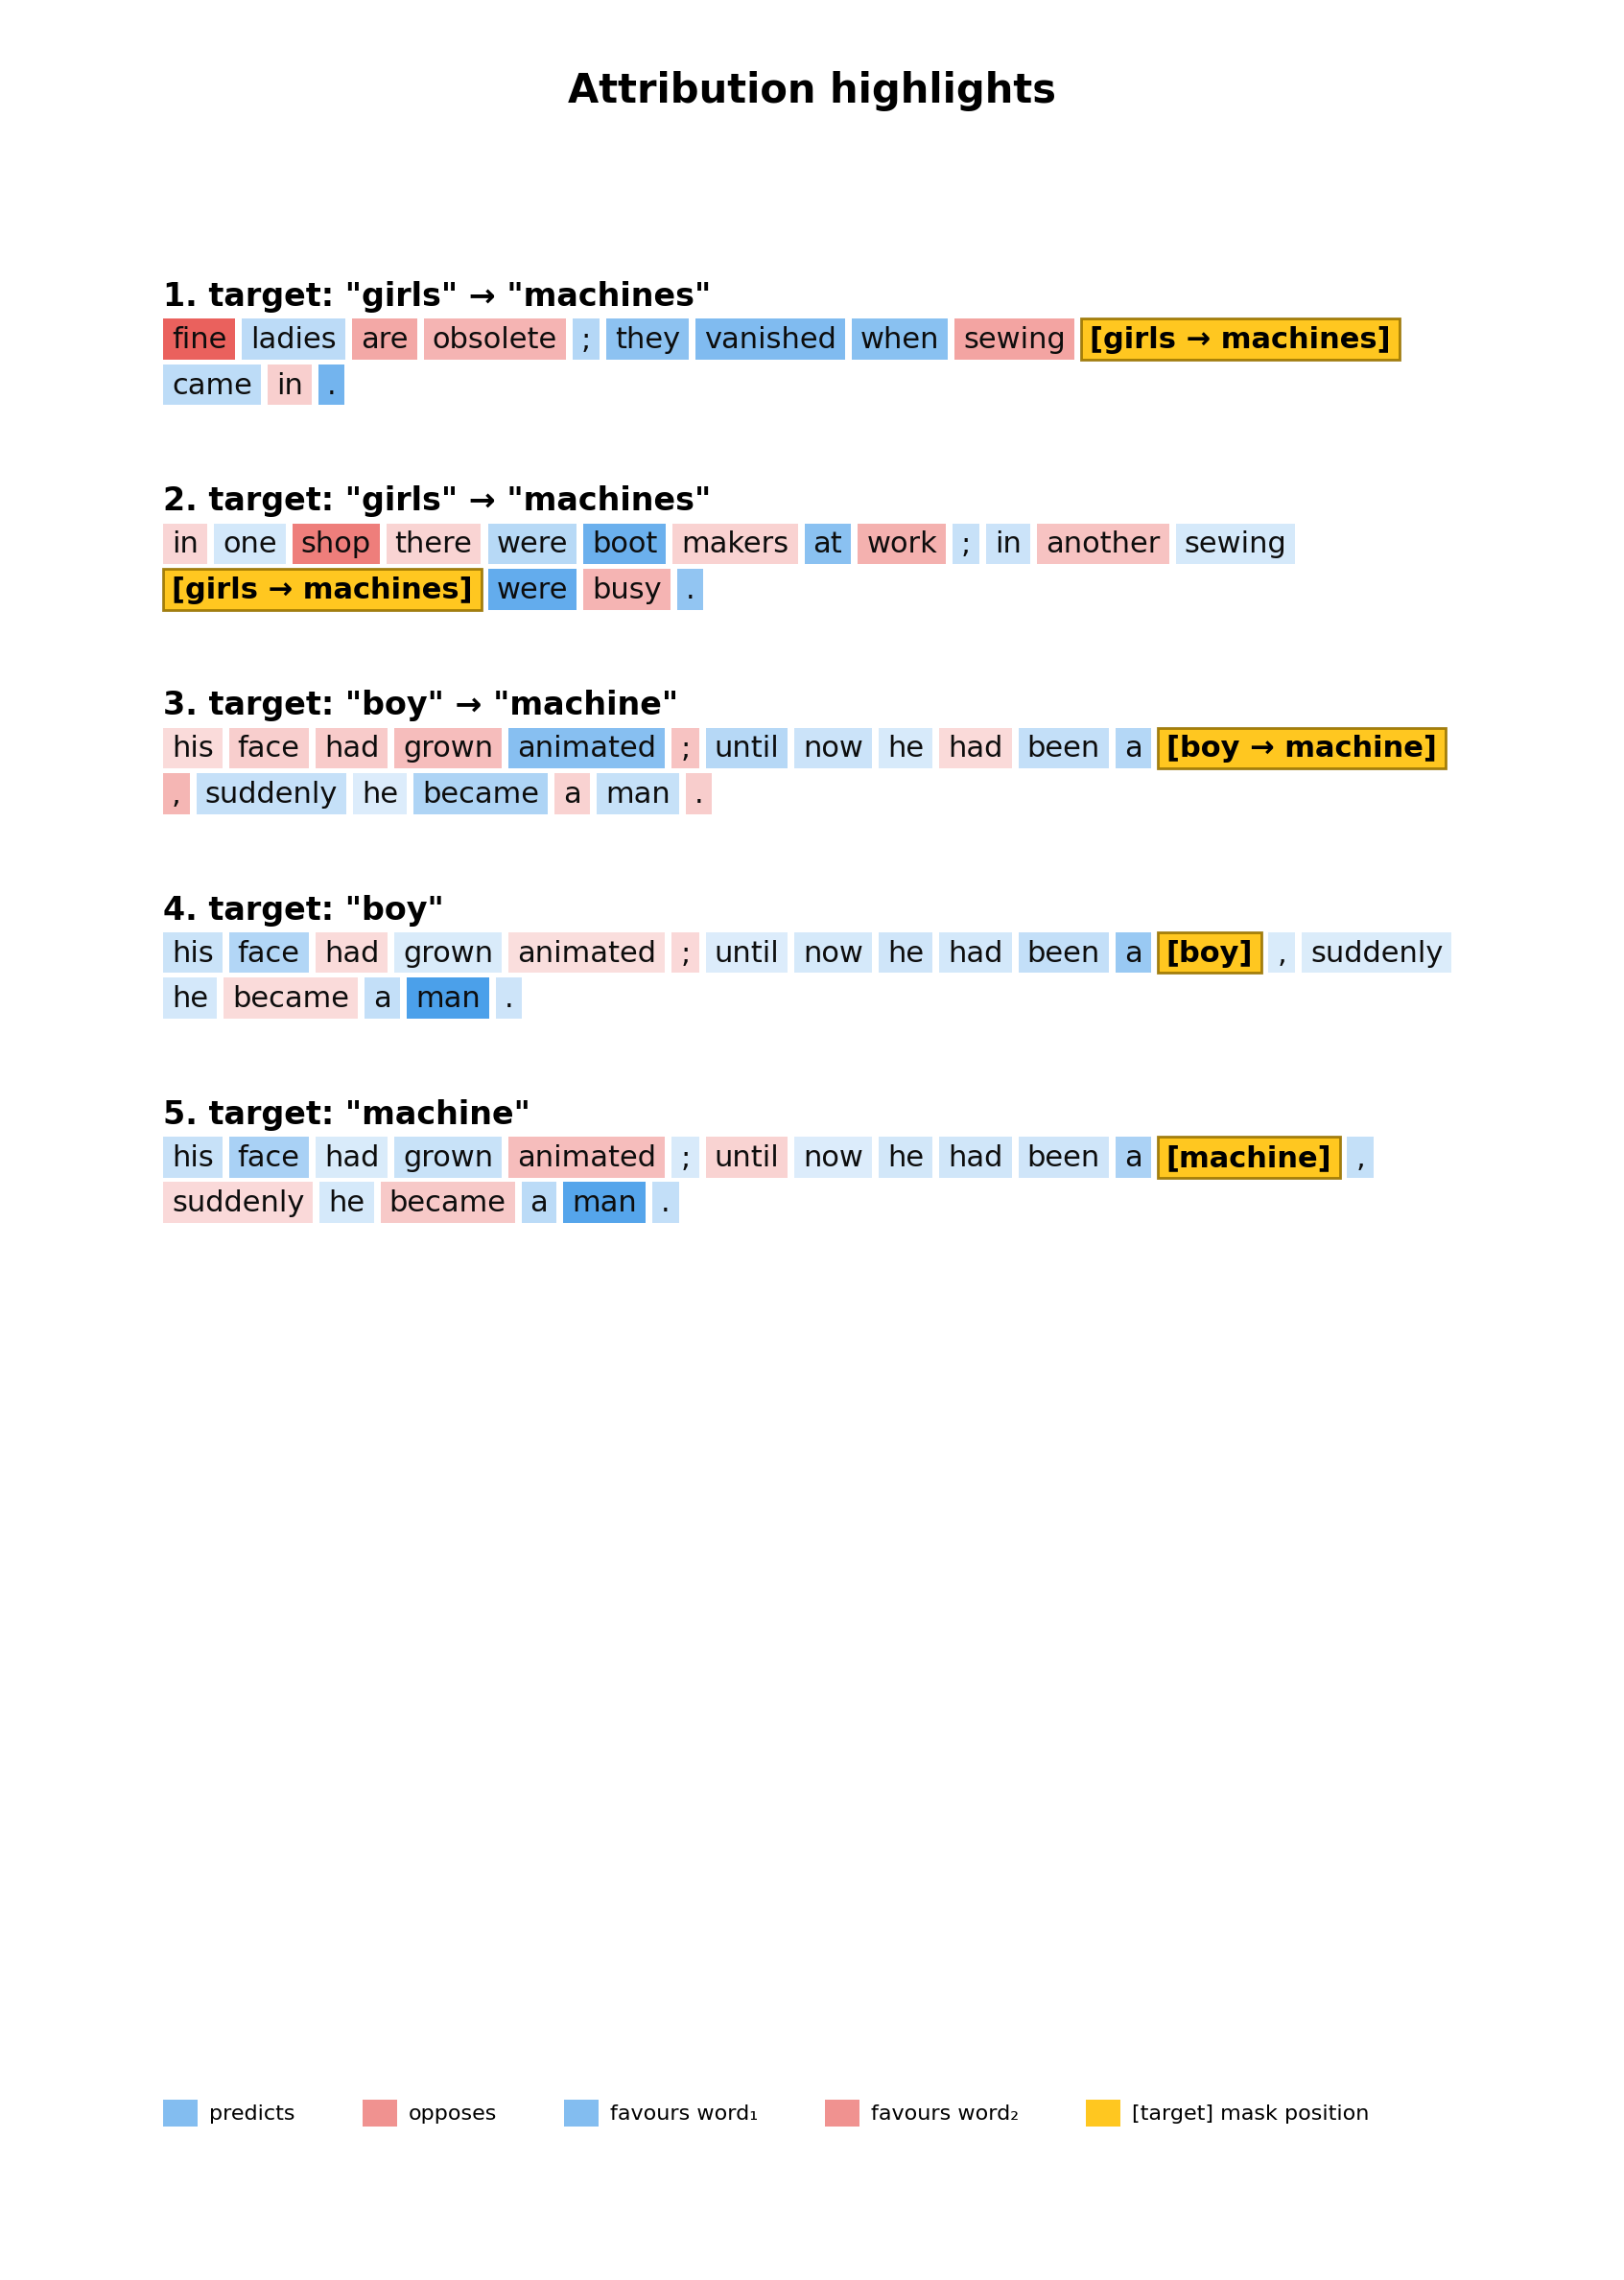

In [10]:
from explain.visualise import plot_highlighted_sentences
fig, ax = plot_highlighted_sentences(
    explainer_imp,
    items=[
        ("Fine ladies are obsolete; they vanished when sewing [MASK] came in.", ["girls","machines"]),
        ("In one shop there were boot makers at work; in another sewing [MASK] were busy.", ["girls","machines"]),
        ('His face had grown animated; until now he had been a [MASK], suddenly he became a man.', ["boy","machine"]),
        ('His face had grown animated; until now he had been a [MASK], suddenly he became a man.', "boy"),
        ('His face had grown animated; until now he had been a [MASK], suddenly he became a man.', "machine")
        ],
    title="Attribution highlights",
    save_path="highlights_a4.pdf",
)


Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

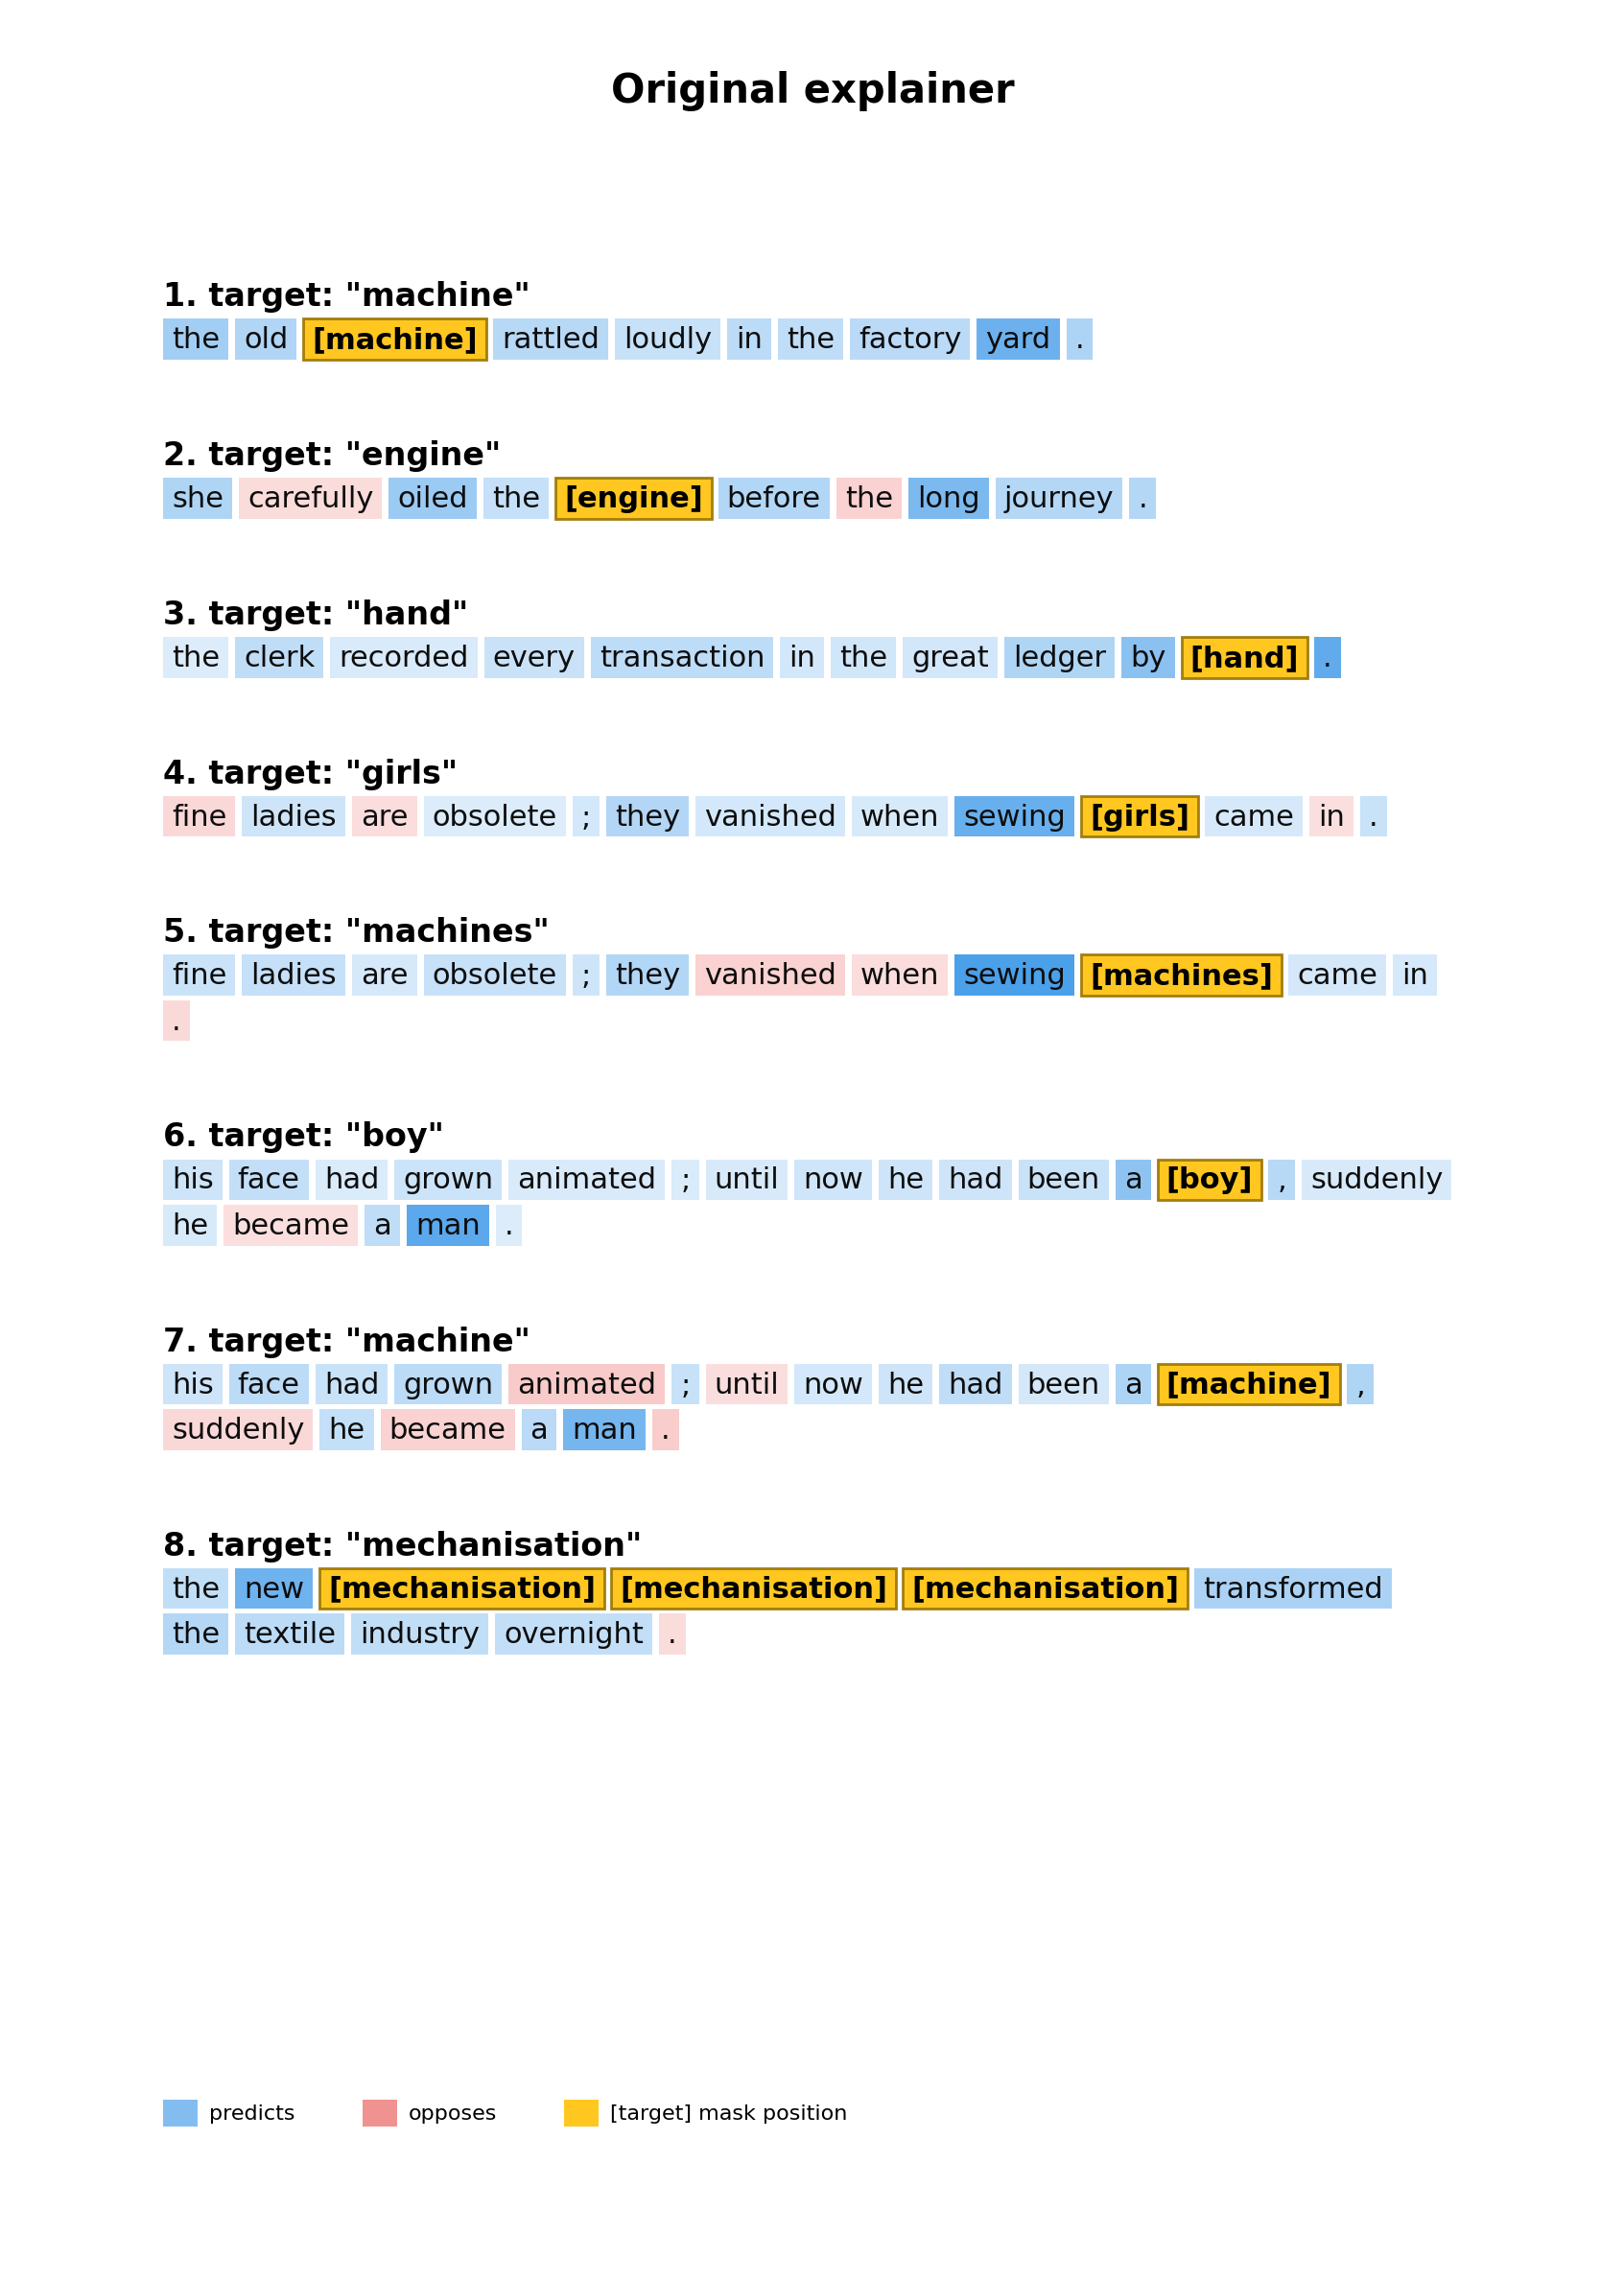

In [7]:
items = [(sent, tgt) for sent, tgt in examples]

fig_orig, _ = plot_highlighted_sentences(
    explainer_orig, items, title="Original explainer", show=True,
)


Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/kasparbeelen/Documents/Text-Machine/bidirectional_masking/mask-predict/explain/visualise.py:374: UserWarning: IG convergence delta=0.2367 exceeds threshold 0.05 for target='machine'; attribution may be inaccurate (consider raising n_steps).
  out = explainer.explain(


Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/kasparbeelen/Documents/Text-Machine/bidirectional_masking/mask-predict/explain/visualise.py:374: UserWarning: IG convergence delta=1.5259 exceeds threshold 0.05 for target='engine'; attribution may be inaccurate (consider raising n_steps).
  out = explainer.explain(


Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

...

/Users/kasparbeelen/Documents/Text-Machine/bidirectional_masking/mask-predict/explain/visualise.py:374: UserWarning: IG convergence delta=0.0724 exceeds threshold 0.05 for target='boy'; attribution may be inaccurate (consider raising n_steps).
  out = explainer.explain(


Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/kasparbeelen/Documents/Text-Machine/bidirectional_masking/mask-predict/explain/visualise.py:374: UserWarning: IG convergence delta=0.1982 exceeds threshold 0.05 for target='machine'; attribution may be inaccurate (consider raising n_steps).
  out = explainer.explain(


Explaining:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/kasparbeelen/Documents/Text-Machine/bidirectional_masking/mask-predict/explain/visualise.py:374: UserWarning: IG convergence delta=0.5832 exceeds threshold 0.05 for target='mechanisation'; attribution may be inaccurate (consider raising n_steps).
  out = explainer.explain(


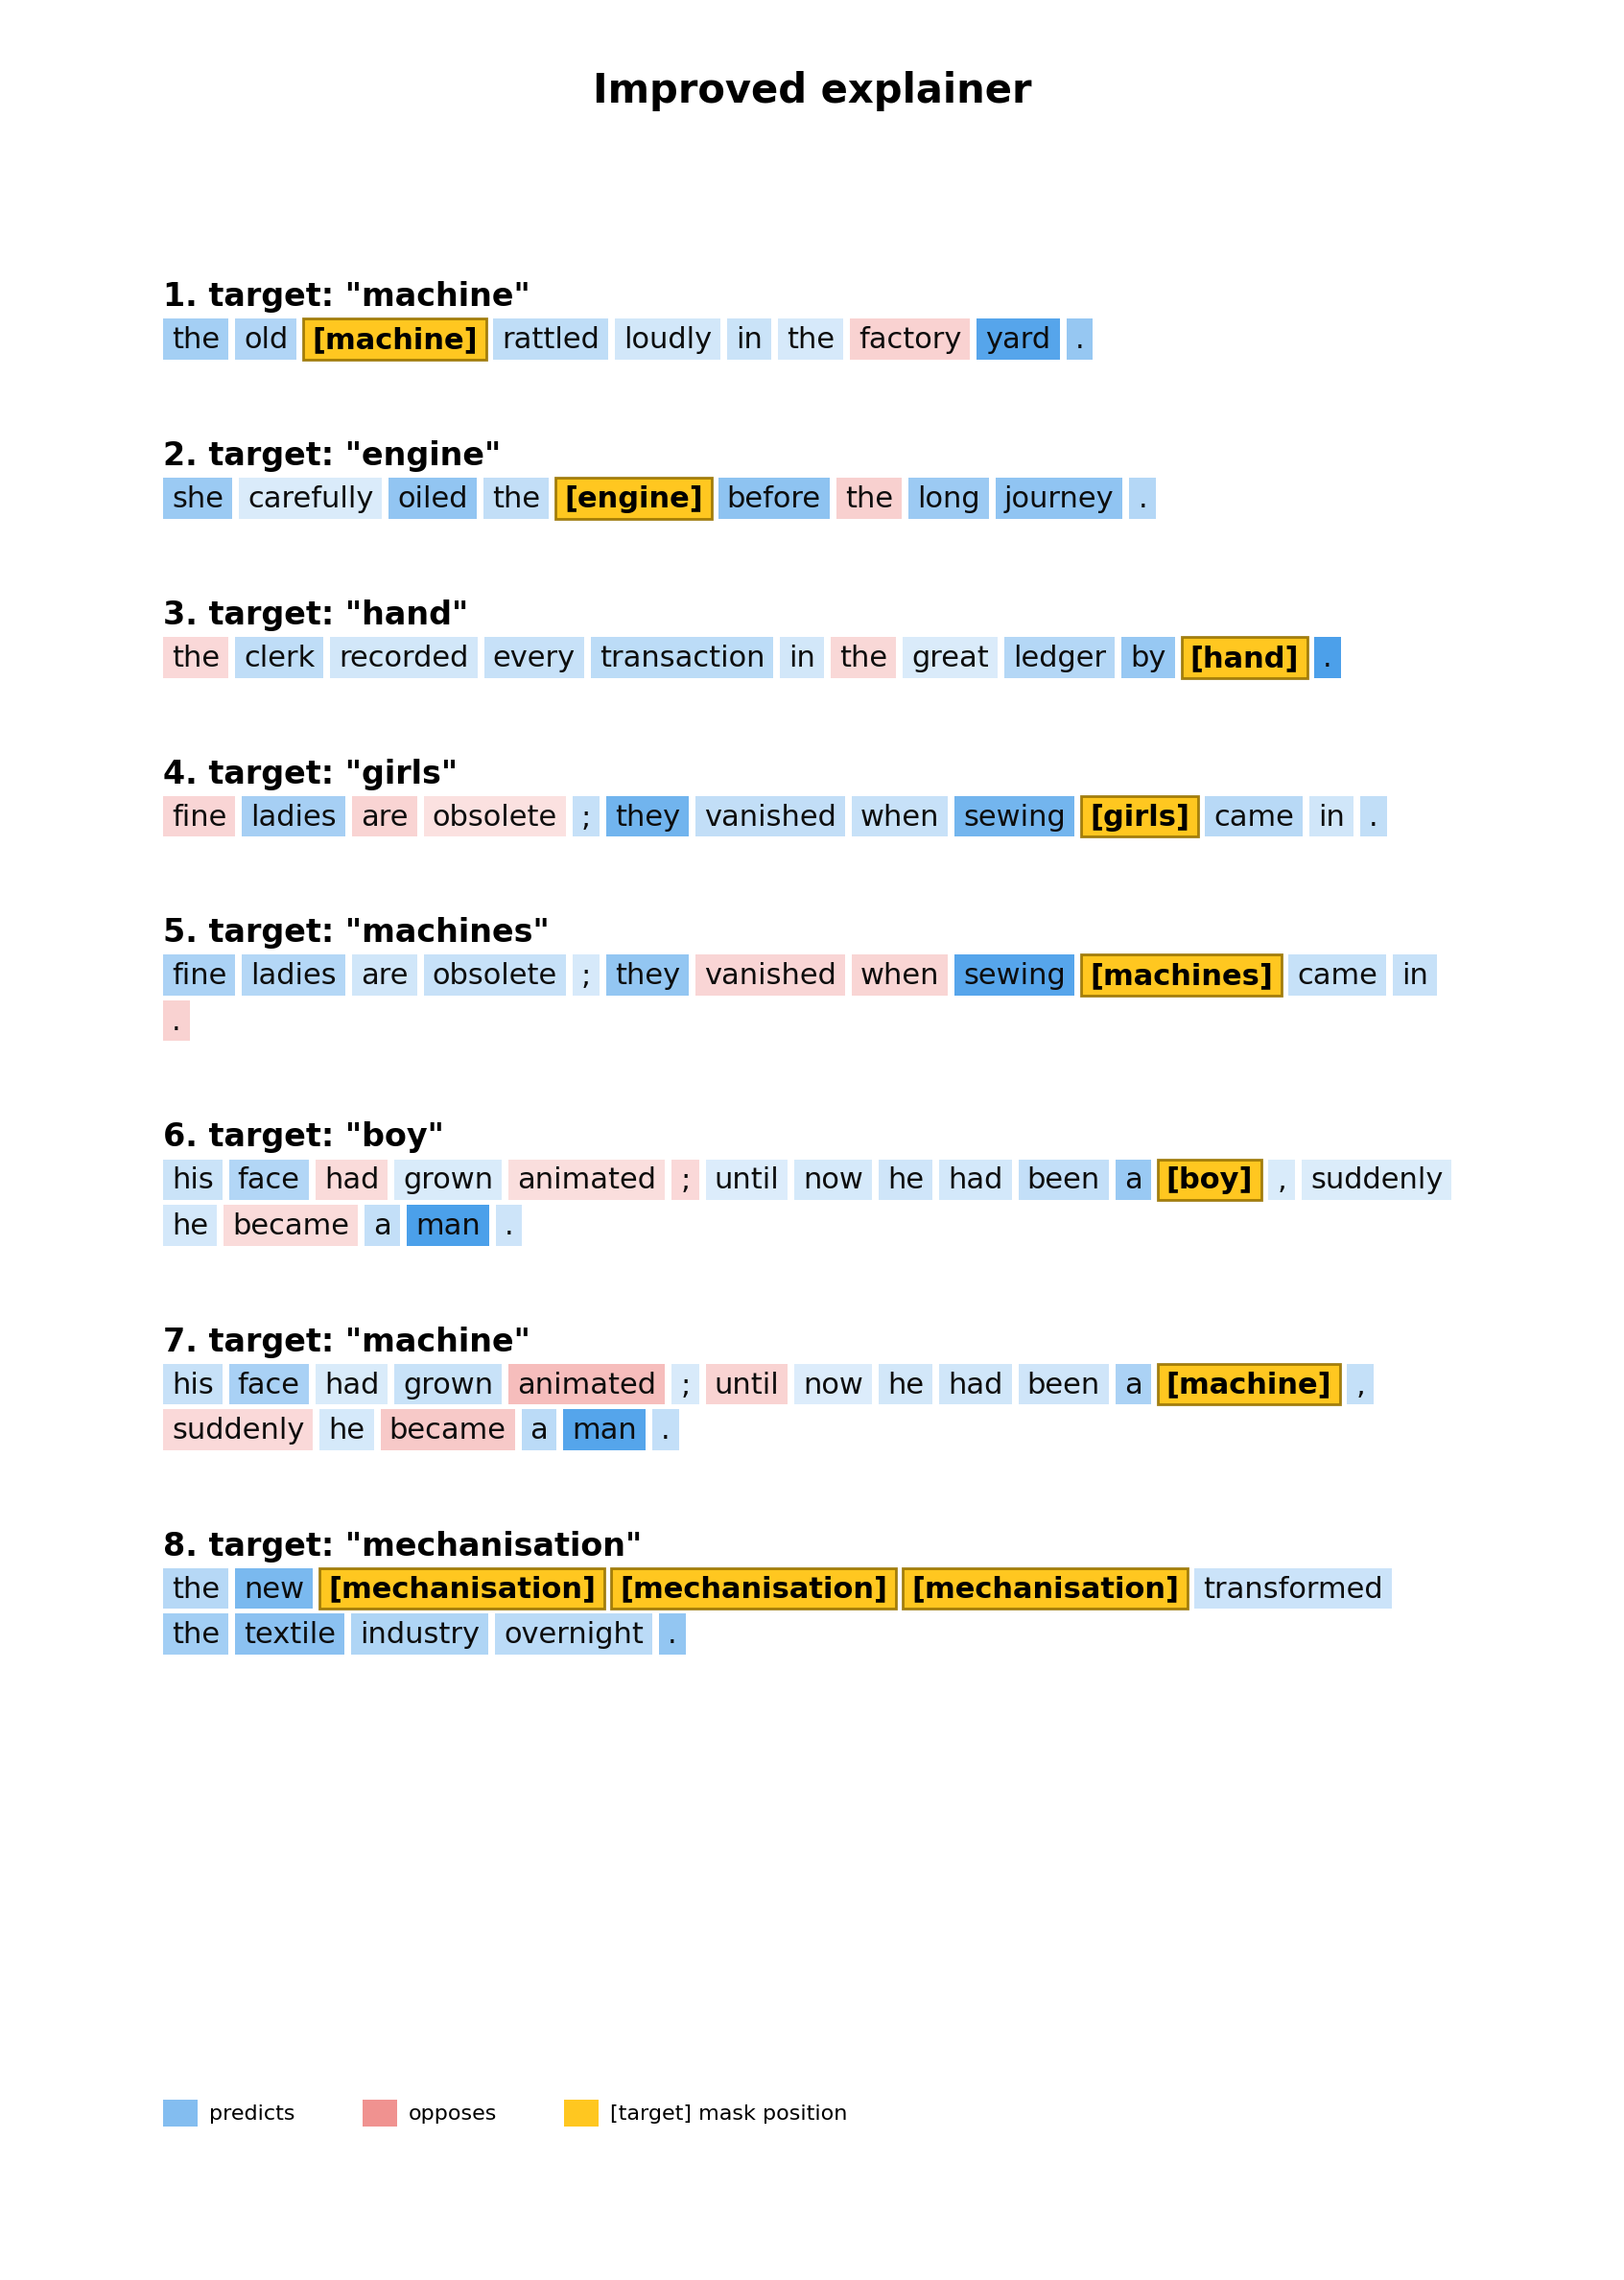

In [9]:
fig_imp, _ = plot_highlighted_sentences(
    explainer_imp, items, title="Improved explainer", show=True,
)


## 3. CLS/SEP leakage across all examples

In [ ]:
leak_rows = []
for sent, tgt in examples:
    out_o = explainer_orig.explain([sent], [[tgt]], show_progress=False, drop_special=False)[0][tgt]
    out_i = explainer_imp.explain([sent], [[tgt]], show_progress=False, drop_special=False)[0][tgt]
    if out_o.get("skipped", False) or out_i.get("skipped", False):
        continue
    leak_o = sum(abs(s) for t, s in out_o["token_attributions"] if t in ("[CLS]", "[SEP]"))
    leak_i = sum(abs(s) for t, s in out_i["token_attributions"] if t in ("[CLS]", "[SEP]"))
    leak_rows.append({
        "target": tgt,
        "sentence": (sent[:45] + "...") if len(sent) > 45 else sent,
        "original": leak_o,
        "improved": leak_i,
    })

leak_df = pd.DataFrame(leak_rows)
leak_df


In [ ]:
import numpy as np

x = np.arange(len(leak_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, leak_df["original"], width, label="original", color="#e53935", alpha=0.8)
ax.bar(x + width / 2, leak_df["improved"], width, label="improved", color="#1e88e5", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(leak_df["target"], rotation=20, ha="right")
ax.set_ylabel("|attribution| on [CLS] + [SEP]")
ax.set_title("Attribution mass silently dropped on [CLS]/[SEP]\n(original vs improved baseline)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Multi-token target check

Confirms the fix behaves the same way when the target requires more than one `[MASK]`
(the `mechanisation`-style example above, if it split into multiple subwords for this
tokenizer).

In [ ]:
multi_token_examples = [(s, t) for s, t in examples if len(explainer_orig._target_to_token_ids(t)) > 1]
if not multi_token_examples:
    print("None of the example targets split into multiple subwords for this tokenizer — "
          "edit `examples` above to add one if you want to exercise this path.")
else:
    for sent, tgt in multi_token_examples:
        print(f"\n=== {tgt!r} in: {sent}")
        display(compare_tokens(sent, tgt))
